# Gradient Descent Animation — Fixed Notebook

This notebook visualizes batch gradient descent (learning the intercept `b`, with the
slope `m` fixed) on a 1D regression problem, and animates:

1. The regression line moving across the data as `b` updates each epoch.
2. The cost (loss) decreasing over epochs.
3. The intercept `b` converging over epochs.
4. The path traced on the cost-vs-b curve as gradient descent runs.

**What was broken in the original file and what was fixed:**

- `%matplotlib notebook` requires an interactive backend (and the `ipympl` / `nbAgg`
  extension) that often isn't installed or doesn't work in modern Jupyter/JupyterLab —
  this silently breaks every plot and animation. Replaced with `%matplotlib inline`,
  and animations are now rendered with `anim.to_jshtml()`, which works everywhere
  without extra dependencies.
- Cells that built the cost/intercept animations referenced an undefined variable
  `num_epochs` → `NameError`. Replaced with a proper `epoch_nums` array.
- `X[j]` is a length-1 array (since `X` has shape `(100, 1)`), so accumulating it into
  `b` silently turned `b` into a NumPy array instead of a float. Fixed by indexing
  `X[j][0]` so everything stays a plain scalar.
- Saving GIFs with `PillowWriter` is now wrapped in a try/except, since it depends on
  the `pillow` package being available — if it's missing, the notebook still works and
  just skips the GIF export instead of crashing.
- Removed empty/dead cells and added a final plot of the full cost curve with the
  gradient-descent path overlaid on it, so you can see why it converges where it does.


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression


## 1. Create a toy regression dataset

In [2]:
X, y = make_regression(n_samples=100, n_features=1, n_informative=1,
                        n_targets=1, noise=20, random_state=13)


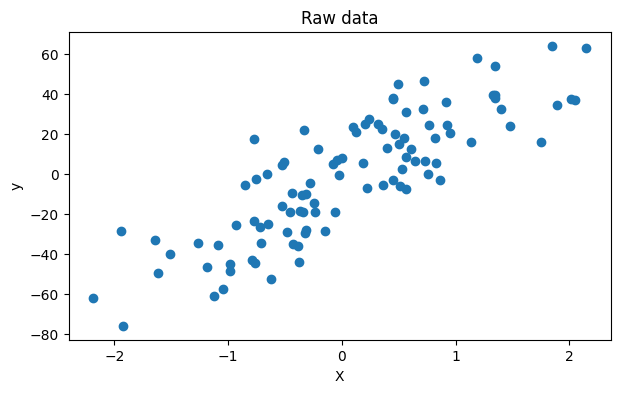

In [3]:
plt.figure(figsize=(7, 4))
plt.scatter(X, y)
plt.title('Raw data')
plt.xlabel('X')
plt.ylabel('y')
plt.show()


## 2. Fit with scikit-learn (ground truth to compare against)

In [4]:
reg = LinearRegression()
reg.fit(X, y)
print('sklearn slope (m):', reg.coef_[0])
print('sklearn intercept (b):', reg.intercept_)


sklearn slope (m): 27.82809103252014
sklearn intercept (b): -2.29474455867698


## 3. Gradient descent on the intercept `b` (slope `m` held fixed)

This mirrors the original notebook's approach: `m` is fixed near the sklearn value,
and gradient descent only learns `b`. Fixed to keep `b`/`cost` as plain scalars.

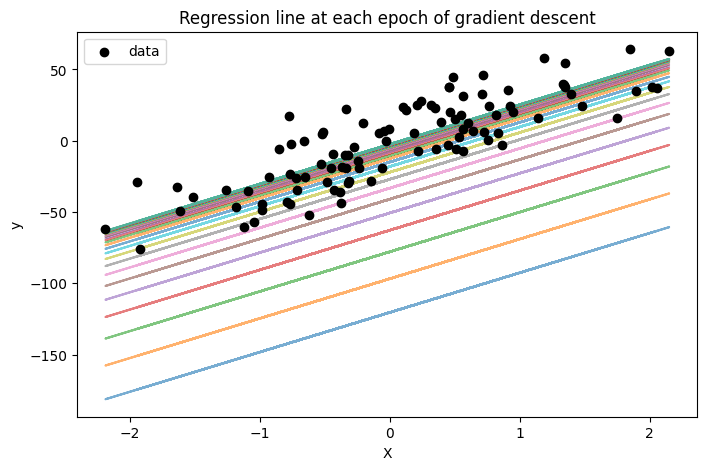

Final b: -2.4771228173203603
Final cost: 28347.50541622337


In [5]:
b = -150.0
m = 27.82
lr = 0.001
epochs = 30

all_b = []
all_cost = []

plt.figure(figsize=(8, 5))

for i in range(epochs):
    slope = 0.0
    cost = 0.0
    for j in range(X.shape[0]):
        x_j = X[j][0]
        slope += -2 * (y[j] - (m * x_j) - b)
        cost += (y[j] - m * x_j - b) ** 2
    b = b - lr * slope

    all_b.append(b)
    all_cost.append(cost)

    y_pred = m * X + b
    plt.plot(X, y_pred, alpha=0.6)

plt.scatter(X, y, color='black', zorder=5, label='data')
plt.title('Regression line at each epoch of gradient descent')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

all_b = np.array(all_b)
all_cost = np.array(all_cost)
epoch_nums = np.arange(1, epochs + 1)

print('Final b:', all_b[-1])
print('Final cost:', all_cost[-1])


## 4. Animation — regression line evolving over epochs

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

x_i = np.linspace(X.min(), X.max(), 50)
ax.scatter(X, y)
line, = ax.plot(x_i, x_i * m + all_b[0], 'r-', linewidth=2)
ax.set_title('Gradient descent: fitting the intercept')

def update_line(i):
    line.set_ydata(x_i * m + all_b[i])
    ax.set_xlabel(f'epoch {i + 1}, b = {all_b[i]:.2f}')
    return line,

anim_line = animation.FuncAnimation(fig, update_line, frames=epochs,
                                     interval=300, repeat=True)
plt.close(fig)  # prevent a duplicate static plot from being displayed

try:
    writer = animation.PillowWriter(fps=3)
    anim_line.save('animation_line.gif', writer=writer)
    print('Saved animation_line.gif')
except Exception as e:
    print('Could not save GIF (pillow may be missing):', e)

HTML(anim_line.to_jshtml())


Saved animation_line.gif


## 5. Animation — cost decreasing over epochs

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlim(0, epochs + 1)
ax.set_ylim(0, all_cost.max() * 1.1)
ax.set_ylabel('cost')
line_cost, = ax.plot([], [], lw=2)

xdata, ydata = [], []

def animate_cost(i):
    xdata.append(epoch_nums[i])
    ydata.append(all_cost[i])
    line_cost.set_data(xdata, ydata)
    ax.set_xlabel(f'epoch {i + 1}')
    return line_cost,

anim_cost = animation.FuncAnimation(fig, animate_cost, frames=epochs,
                                     interval=300, repeat=False)
plt.close(fig)

try:
    writer = animation.PillowWriter(fps=3)
    anim_cost.save('animation_cost.gif', writer=writer)
    print('Saved animation_cost.gif')
except Exception as e:
    print('Could not save GIF (pillow may be missing):', e)

HTML(anim_cost.to_jshtml())


Saved animation_cost.gif


## 6. Animation — intercept `b` converging over epochs

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlim(0, epochs + 1)
ax.set_ylim(all_b.min() - 5, all_b.max() + 5)
ax.set_ylabel('b')
line_b, = ax.plot([], [], lw=2)

xdata, ydata = [], []

def animate_b(i):
    xdata.append(epoch_nums[i])
    ydata.append(all_b[i])
    line_b.set_data(xdata, ydata)
    ax.set_xlabel(f'epoch {i + 1}')
    return line_b,

anim_b = animation.FuncAnimation(fig, animate_b, frames=epochs,
                                  interval=300, repeat=False)
plt.close(fig)

try:
    writer = animation.PillowWriter(fps=3)
    anim_b.save('animation_b.gif', writer=writer)
    print('Saved animation_b.gif')
except Exception as e:
    print('Could not save GIF (pillow may be missing):', e)

HTML(anim_b.to_jshtml())


Saved animation_b.gif


## 7. Animation — path traced on the cost-vs-b curve

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(all_b, all_cost, color='lightgray')
ax.set_xlim(all_b.min() - 10, all_b.max() + 10)
ax.set_ylim(0, all_cost.max() * 1.1)
ax.set_xlabel('b')
ax.set_ylabel('cost')

sc = ax.scatter([], [], color='red', marker='+')
xs, ys = [], []

def animate_path(i):
    xs.append(all_b[i])
    ys.append(all_cost[i])
    sc.set_offsets(np.c_[xs, ys])
    ax.set_title(f'epoch {i + 1}')
    return sc,

anim_path = animation.FuncAnimation(fig, animate_path, frames=epochs,
                                     interval=300, repeat=True)
plt.close(fig)

try:
    writer = animation.PillowWriter(fps=3)
    anim_path.save('animation_path.gif', writer=writer)
    print('Saved animation_path.gif')
except Exception as e:
    print('Could not save GIF (pillow may be missing):', e)

HTML(anim_path.to_jshtml())


Saved animation_path.gif


## 8. The full cost curve as a function of `b`

This sweeps `b` across a wide range (with `m` still fixed) and plots the resulting
cost, then overlays the gradient-descent trajectory from above so you can see it
sliding down the parabola toward the minimum.

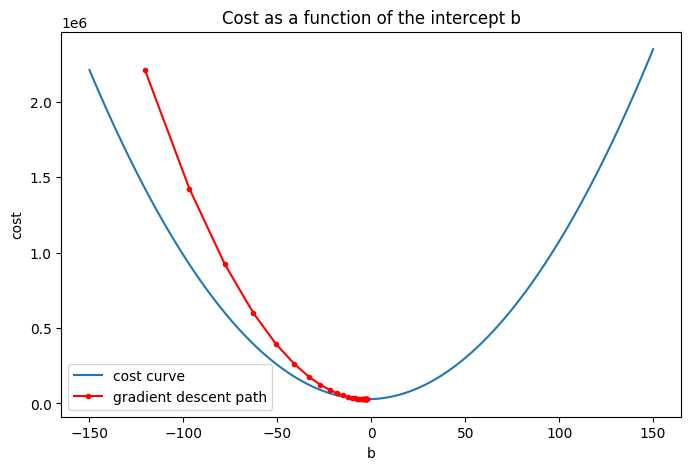

In [10]:
b_input = np.linspace(-150, 150, 100)
cost_input = []

for bi in b_input:
    this_cost = 0.0
    for j in range(X.shape[0]):
        this_cost += (y[j] - m * X[j][0] - bi) ** 2
    cost_input.append(this_cost)

cost_input = np.array(cost_input)

plt.figure(figsize=(8, 5))
plt.plot(b_input, cost_input, label='cost curve')
plt.plot(all_b, all_cost, 'r.-', label='gradient descent path')
plt.xlabel('b')
plt.ylabel('cost')
plt.title('Cost as a function of the intercept b')
plt.legend()
plt.show()
